# Netflix Titles EDA

**Dataset:** [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)  
**Domain:** Entertainment / dates, text-like columns, categorical EDA

You will analyze Netflix catalog data to understand content types, release trends, country representation, ratings, durations, and genres.

This notebook follows a guided EDA capstone style: read the data, inspect it, answer progressively harder questions, create features, visualize patterns, and end with written takeaways.

Import the usual EDA libraries.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Read the CSV into df

In [22]:
df = pd.read_csv('netflix_titles.csv')

Inspection the dataframe with `info()`, `head()`, `shape`, and missing value counts.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [23]:
df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [24]:
df.shape

(8807, 12)

**Write your interpretation here:**

- 

**Exercise:** Which columns have the most missing values? Should every missing value be dropped?

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [25]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

**Write your interpretation here:**

- 

In [26]:
# Use value_counts() to check how many movies and tv shows exist in the type column
#  
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [27]:
is_movie = (df['type'] == 'Movie').sum()
is_tvshow = (df['type'] == 'TV Show').sum()

print(is_movie)
print(is_tvshow)

6131
2676


**Write your interpretation here:**

- 

**Exercise:** What are the top 10 countries represented?

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [28]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

**Write your interpretation here:**

- 

**Exercise:** What are the top 10 content ratings?

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [29]:
df['rating'].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

**Write your interpretation here:**

- 

**Exercise:** What are the earliest and latest release years?

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [30]:
latest_release_year = df['release_year'].max()

earliest_release_year = df['release_year'].min()

print(latest_release_year)
print(earliest_release_year)

2021
1925


**Write your interpretation here:**

- 

## Creating New Features

**Exercise:** Convert `date_added` to datetime.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [31]:
# Convert the data_added column to datetime format using pd.to_datetime
# Use errors='coerce' to replace any invalid or malformed date values with NaT, allowing the conversion to complete

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

**Write your interpretation here:**

- 

**Exercise:** Create `year_added`, `month_added`, and `day_added` from `date_added`.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [32]:
# Use the .dt accessor to extract the year, month, and day from each value in the date_added column

df['year_added'] = df['date_added'].dt.year

df['month_added'] = df['date_added'].dt.month

df['day_added'] = df['date_added'].dt.day


**Write your interpretation here:**

- 

**Exercise:** Create a `main_genre` column by taking the first genre from `listed_in`.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [33]:
# Create a main_genre column by taking the first genre from the listed_in column, which contains multiple genres seperated by commas.
# by splitting the listed_in string on commas and taking the first element as the primary genre using .str accessor

df['main_genre'] = df['listed_in'].str.split(',').str[0]

**Write your interpretation here:**

- 

**Exercise:** For Movies only, extract numeric duration in minutes into a `duration_minutes` column.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [34]:
# Extract numeric duration from movies only
# The 'duration' column contains values like '90 min', so we extract 
# the numeric part using regex and convert it to integer

#df['type'] == 'Movie'

#df['duration_minutes'] = df['duration'].str.extract(r'(\d+)').astype(float) 

df['duration_minutes'] = df['duration'].str.extract(r'(\d+)').astype(float)

**Write your interpretation here:**

- 

## EDA and Visualization

**Exercise:** Create a countplot for type: Movie vs TV Show.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

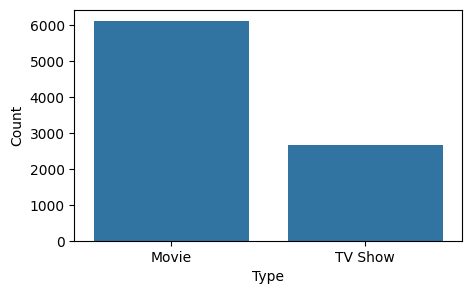

In [35]:
# Create a count plot with 'type' column using the df DataFrame.

plt.figure(figsize=(5, 3))            # Set the figure size - width, height in inches

sns.countplot(data=df,x='type')
plt.xlabel('Type')
plt.ylabel('Count')



plt.show()

**Write your interpretation here:**

- 

**Exercise:** Plot number of titles added per year. What trend do you see?

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

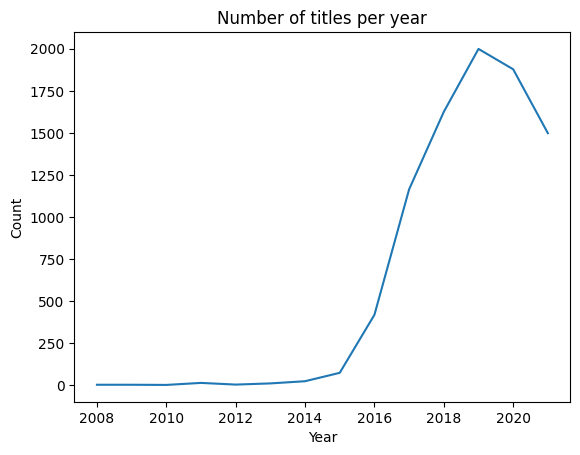

In [36]:
# Count how many titles were added per year
# Convert into proper DataFrame then plot with seaborn line plot

year_counts = df['year_added'].value_counts()

year_counts_df = year_counts.reset_index()
year_counts_df.columns = ['year', 'count']
year_counts_df = year_counts_df.sort_values('year')


sns.lineplot(data=year_counts_df, x='year', y='count')
plt.title('Number of titles per year')
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()


**Write your interpretation here:**

- 

**Exercise:** Create a bar chart of the top 10 main genres.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

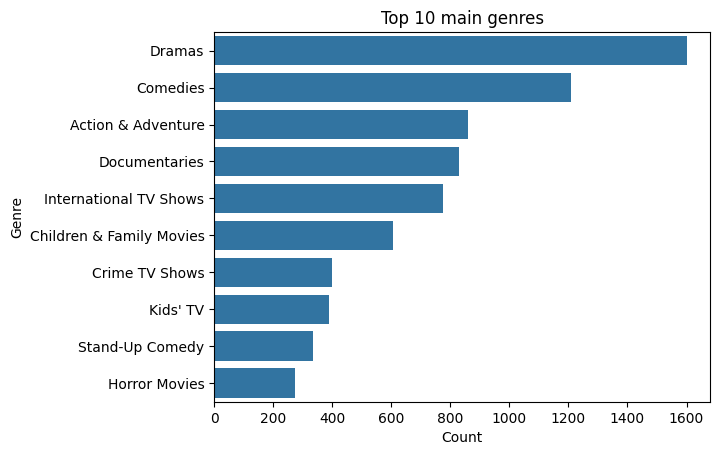

In [37]:
# Count genres and select the top 10

top_genres = df['main_genre'].value_counts().head(10)

# Convert new variable into DataFrame then plot with seaborn line plot

top_genres_df = top_genres.reset_index()
top_genres_df.columns = ['genre', 'count']

sns.barplot(data=top_genres_df, x='count', y='genre')
plt.title('Top 10 main genres')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.show()


**Write your interpretation here:**

- 

**Exercise:** For movies, plot the distribution of duration_minutes.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

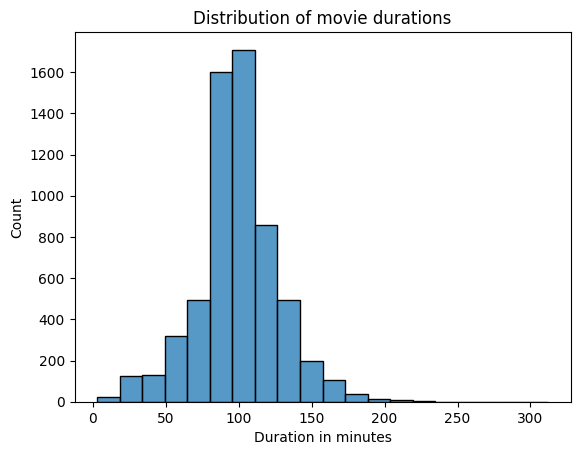

In [38]:
# Filter movies only
#Plot distributions of movie durations

Movies = df[df['type'] == 'Movie']

sns.histplot(data=Movies, x='duration_minutes', bins=20)

plt.title('Distribution of movie durations')
plt.xlabel('Duration in minutes')
plt.ylabel('Count')

plt.show()


**Write your interpretation here:**

- 

**Exercise:** Create a heatmap or pivot table of content type by rating.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

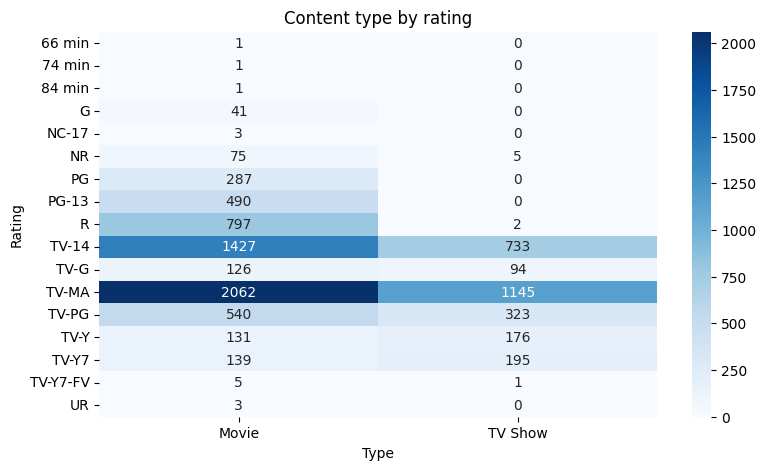

In [39]:
# Create a pivot table, since heatmap does not work directly on raw data
pivot = df.pivot_table(index='rating', 
                       columns='type', 
                       values='title', 
                       aggfunc='count'
                       )

# Handle missing values
pivot = pivot.fillna(0)

# create heatmap
plt.figure(figsize=(9, 5))

sns.heatmap(pivot, annot=True, fmt='g', cmap='Blues')

plt.title('Content type by rating')
plt.xlabel('Type')
plt.ylabel('Rating')
           
plt.show()



**Write your interpretation here:**

- 

## Interpretation and Portfolio Takeaways

**Exercise:** Write 5 insights about the Netflix catalog.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [40]:
# Creating a Heatmap of the grouped and unstacked DataFrame


plt.figure(figsize=(9, 5))

sns.heatmap(df_reshaped, cmap='viridis')

plt.title('Calls heatmap')
plt.xlabel('Hour')
plt.ylabel('Day of Week')
           
plt.show()

NameError: name 'df_reshaped' is not defined

<Figure size 900x500 with 0 Axes>

**Write your interpretation here:**

- 

**Exercise:** Mention 3 data quality issues or limitations.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [ ]:
# YOUR CODE HERE

**Write your interpretation here:**

- 

**Exercise:** Optional extension: Compare catalog trends before and after 2015.

**Learning outcome:** Practice turning a dataset question into pandas code and then into a short interpretation.

In [ ]:
# YOUR CODE HERE

**Write your interpretation here:**

- 